In [2]:

# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "JaredLasley"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW2"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/JaredLasley/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW2/STAT-7220-Applied-Experimental-Design/Assignments/HW2


# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 20, 2026**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

* The objective of this experiment is to compare the outcomes of three different methods of instructing undergraduate data science students.

**Question 2.** Specify the outcome variable
* The Score variable is the ouucome variable.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?
* The independent variable is Teaching_Methond and the blocking factor is Prior_Knowledge. Possible lurking variables include each the amount of time each student spends studying material or the time of the day each student attends the class. These could affect student performace depending on learning method.

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

* A randomized block design would be appropriate in this case because of the presence of a single known blocking factor. A completely randomized design would not be appropriate here because of the presence of the known blocking factor. If we were to use a CRD the known variace determined from the blocking factor Prior_knowledge would instead be attributed to unknown variance which would weaken the model.
*
**Question 5.** State the null and alternative hypotheses for this experiment.

$$ H_0: \mu_1 = \mu_2 = \mu_3 $$

$$ H_1:\text{At least one pair of treatement means are not equal} $$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

* Both the summary statistics and data visualizations more strongly support the aternative hyothesis. In the boxplot you can see that for the low prior knowledge group there is no overlap between the boxes of the collaborative teaching method with any other method. This is supported by the summary statistics where we can see that the collaborative method in the low prior knowledge group is more than 1 standard deviation greater than the mean of the other two treatements. A similar but less pronounced effect can be seeen in the high prior knowledge group.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Prior_Knowledge Teaching_Method                  
Low             Collaborative    84.810  7.850254
                Direct           73.574  6.028273
                Inquiry          77.611  5.153114
High            Collaborative    89.390  6.540866
                Direct           81.409  6.400299
                Inquiry          86.618  5.738629


/tmp/ipython-input-3957414948.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = teach.groupby(['Prior_Knowledge','Teaching_Method'])['Score'].agg(['mean','std'])


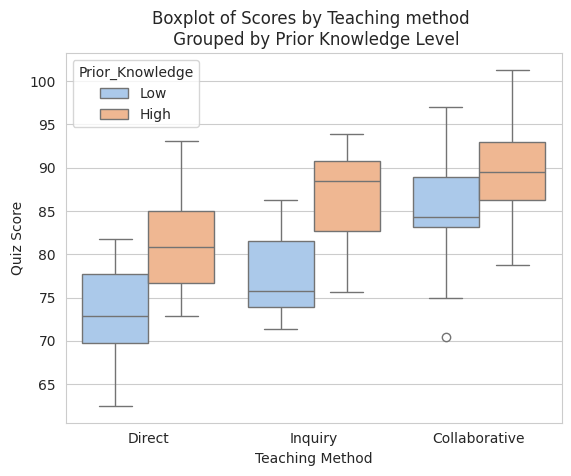

In [6]:
## Import Necessary Packages to Perform Exploratory Analysis ##

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Import Dog Toys.xlsx file ##

teach = pd.read_excel("Data Science Teaching Method.xlsx")
## Check Data Integrity ##

print(teach.info())

## Calculate Group Means and Standard Deviations ##
knowledge_order = ["Low", "High"]

teach['Prior_Knowledge'] = pd.Categorical(teach['Prior_Knowledge'],
                                          categories=knowledge_order,
                                          ordered=True)
summary_stats = teach.groupby(['Prior_Knowledge','Teaching_Method'])['Score'].agg(['mean','std'])

print(summary_stats)


## Generate Boxplots for Visual Comparison ##

## Set a nice minimal style for plot ##

sns.set_style("whitegrid")

## Create boxplot using seaborn ##

sns.boxplot(x="Teaching_Method",y="Score",data=teach,
            hue='Prior_Knowledge',
            hue_order=knowledge_order,
            palette='pastel')

## Add Title and Labels using matplotlib ##

plt.title("Boxplot of Scores by Teaching method \n Grouped by Prior Knowledge Level", loc='center')
plt.xlabel("Teaching Method")
plt.ylabel("Quiz Score")
plt.show()

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

* Both the test and visual method more strongly support the assumption of normality. The majority of the points are on the trend line of the qq plot except for a few at the bottom and top, overall this looks normal to me. The Shapio-wilkes test confirms this analysis. With a p-value of 0.87 we fail to reject the null hypothesis which which states that the assumption of normality is met.

In [11]:
## Fit ANOVA Model ##


## fitting model ##

teach_mod = ols("Score~Teaching_Method+Prior_Knowledge",data=teach).fit()

## Obtain ANOVA Table ##

## Note, we use Type III SS so that way the Exercise Treatment
## is evaluated after adjusting for BMI Category ##

teach_tab = sm.stats.anova_lm(teach_mod,typ=3)

## Add Significance Column ##

teach_tab["Significance"] = np.where(teach_tab["PR(>F)"]<0.05,"Significant","Not Significant")



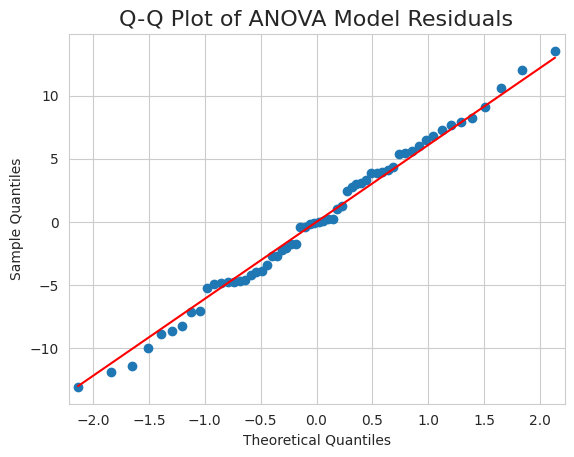

Shapiro-Wilk Test Statistic: 0.9893
Shapiro-Wilk Test P-Value: 0.8794
The residuals are normally distributed (fail to reject H0).


In [9]:
## Assessing Normality ##

## Import scipy ##

import scipy.stats as stats

## Extract Model Residuals ##

teach_residuals = teach_mod.resid

## Generate QQ plot using seaborn ##

sm.qqplot(teach_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(teach_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

* Both the statistical teset and visualization support the assumption of Homoscedasticity. The Standardized vs Residual plot appears to be generally centered on a mean of zero, futher there are no outliers beyond 3 standard deviation. For the B-P test we obtained a p-value of 0.522 which means we fail to reject the null hypothesis and the data is assumed to be homscedastic.



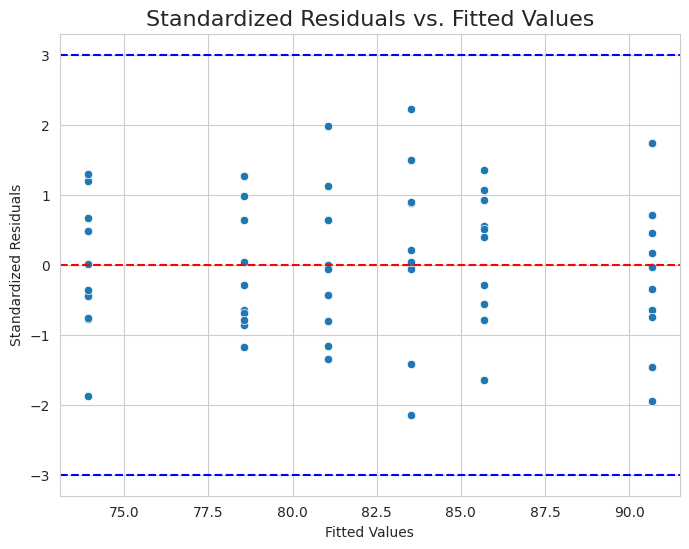

F-statistic: 0.7579465871345092
F p-value: 0.5224437459616427
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [10]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##

## Obtain Standardized Residuals ##

standardized_residuals = teach_mod.get_influence().resid_studentized_internal

## Get the fitted values ##

fitted_values = teach_mod.fittedvalues

## Create the plot using seaborn ##

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##

## Import necessary function: ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##

bp_test = het_breuschpagan(teach_mod.resid,teach_mod.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

With an F-stastic of 11.62 and a p-value < 0.001 we reject the null hpothesis that there is no difference between the mean score of each eaching method. The alternative hypothesis is more strongly supported.

In [12]:
## Print Only Teaching Method & Prior Knowledge Rows ##

print(teach_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

* The only significant difference determined from the post-hoc test was between collaborative and direct teaching methods with the mean difference in group scores being 9.6 points lower on average in the collaborative teaching group compared to the direct teaching group. The difference between Colloborative and Inquiry was borderline significant.

Figure(1000x600)
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -9.6085 0.0003 -15.1184 -4.0986   True
Collaborative Inquiry  -4.9855 0.0838 -10.4954  0.5244  False
       Direct Inquiry    4.623 0.1168  -0.8869 10.1329  False
-------------------------------------------------------------


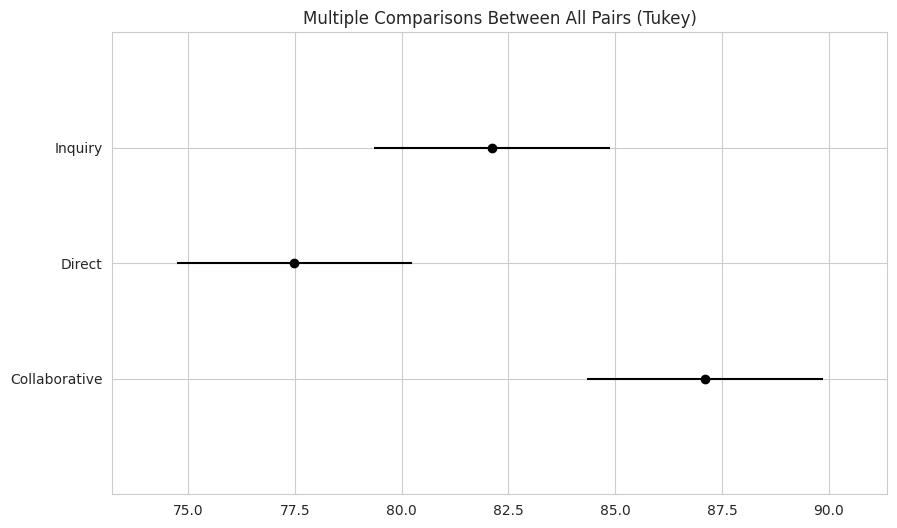

In [13]:
## Import pairwise_tukeyhsd function ##

from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test (Remember, we renamed Exercise Treatment to Exercise_Treatment) ##

tukey_result = pairwise_tukeyhsd(endog=teach['Score'], groups=teach['Teaching_Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##

print(tukey_result.plot_simultaneous())

print(tukey_result)

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

* In conclusion our analyses have determined that there is a difference between the mean quiz scores of the three different teaching methods trialed. Specifically a significant difference was found between the mean quiz scores of the collaborative and direct teaching methods with the collaborative group have quiz scores approximately 9 points higher on average. While the difference between the collaborative and inquiry teaching methods was only marginally significant, the mean test score diffrence between the two groups was still nearly 5 points higher in the collaborative group on average. Potential limitations of this experiment include a limited sample size as well as additional lurking factors related to the students which have an interaction with quiz. Future iterations of this experiment could impove upon this study by collecting data across a broaded population and by accounting for additional variables which impact student success beyond teaching method and prior knowledge of the subject.

**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

* The objective of this experiment is to determine the effectiveness of four different online learning platforms in terms of online data science student engagement.

**Question 2.** Specify the outcome variable
* Engagement is the outcome variable.

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?
* The indpendent variable is Platform(A,B,C,D) and the blocking factors are Day and Section. Additional possible lurking variables include the amount of time a student studies, how many classes the student attended, and the Professor teaching the class.

**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.
* A latin square design is appropriate due to the preseence of  two blocking factors as well as the fact that the blocking factors have an equal amout of elements. A CRD or randomized block design would inappropriate here due to the number of blocking factors. Both a CRD and a RBD would not efficiently capture the full variance of both blocking variables.

**Question 5.** State the null and alternative hypotheses for this experiment.
* $$ H_0: \mu_A = \mu_B = \mu_C = \mu_D $$

$$ H_1:\text{At least one pair of treatement means are not equal} $$
**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



In [ ]:
## Import Necessary Packages ##
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Read in Data ##

online_learning = pd.read_excel("Latin Square Dog Toys.xlsx")

## Data Integrity Check ##

print(dog_toys.info())

## Calcualte Means and Standard Deviations ##

sum_stats = dog_toys.groupby("Formulation")["PSI"].agg(['mean','std'])

print(sum_stats)


**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?



**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?



**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?



**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.